## Введение
### Цель работы
Изучение алгоритмов кластеризации, приобретение навыков оценки качества разбиения данных на кластеры и интерпретации результатов.

### Постановка задачи
1. Загрузить датасет для задачи кластеризации / классификации (например, с платформы Kaggle). Провести дескриптивный анализ данных: определить размерность, типы признаков, наличие пропусков. Оценить распределение переменных (близость к нормальному) с использованием визуализации (гистограммы). Проверить условие применения кластеризации: отсутствие классов, осмысленность кластеризации, отсутствие выбросов.

2. Выполнить стандартизацию / нормализацию числовых признаков. Обосновать выбор метода масштабирования. Построить матрицу диаграмм рассеивания для визуальной оценки структуры данных, предположительного количества кластеров и типа кластерной структуры. Аргументировать выбор методов кластеризации на основе формы, размера и плотности кластеров.

3. Реализовать кластеризацию двумя различными методами на выбор: K-means (K-средних); иерархическая кластеризация; DBSCAN; EM-алгоритм (Gaussian Mixture). Для методов, требующих задания числа кластеров (K-means, иерархическая), подобрать оптимальное значение k с использованием: метода локтя и / или анализа силуэта.

4. Рассчитать метрики качества для обоих методов: внутренние и внешние. Оценить расстояние между кластерами, внутрикластерные расстояния, компактность кластеров, центры кластеров. Опционально, если известно разделение на классы, посчитать: индекс Rand, индекс Жаккара и др. внешние метрики. Привести содержательную интерпретацию полученных значений.

5. Исследовать влияние параметров одного из методов (например, ε и min_samples для DBSCAN или количества кластеров k для K-means) на качество кластеризации.

6. Визуализировать полученные кластеры в пространстве признаков (использовать PCA для снижения размерности при необходимости). Проанализировать центры кластеров (для K-means) и дать содержательную интерпретацию выделенных групп. Сравнить результаты, полученные двумя разными методами.

### Описание датасета


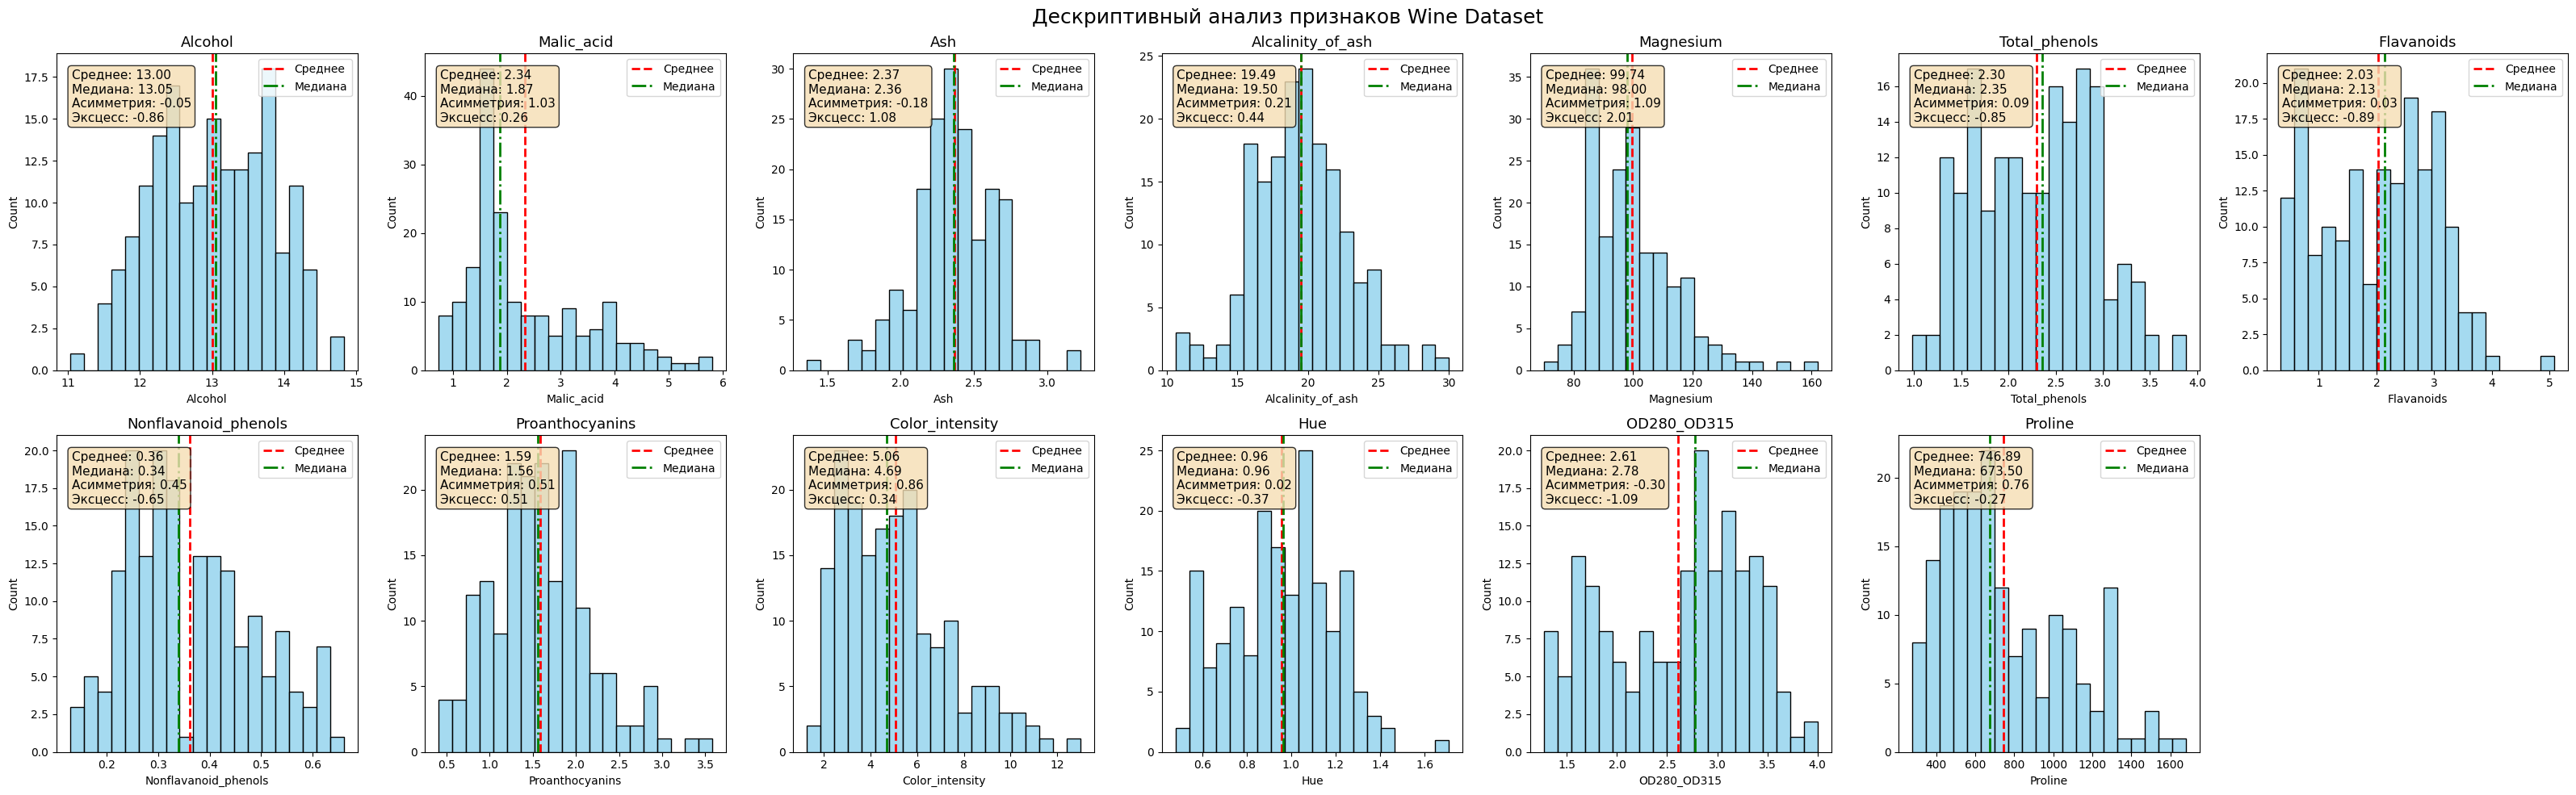

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import seaborn as sns
import numpy as np

from scipy.stats import skew, kurtosis
columns = [
    'Alcohol', 'Malic_acid', 'Ash', 'Alcalinity_of_ash',
    'Magnesium', 'Total_phenols', 'Flavanoids',
    'Nonflavanoid_phenols', 'Proanthocyanins',
    'Color_intensity', 'Hue', 'OD280_OD315', 'Proline'
]

data = pd.read_csv('wine.data', header=None)
data.columns = ['Class'] + columns

X = data[columns]
numeric_cols = X.columns
fig, axes = plt.subplots(2, 7, figsize=(32, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    data_col = X[col]
    
    mean_val = data_col.mean()
    median_val = data_col.median()
    skew_val = skew(data_col)
    kurt_val = kurtosis(data_col)
    
    sns.histplot(data_col, ax=axes[i], bins=20,
                 color='skyblue', edgecolor='black')
    
    axes[i].axvline(mean_val, color='red', linestyle='--',
                    linewidth=2, label=f'Среднее')
    axes[i].axvline(median_val, color='green', linestyle='-.',
                    linewidth=2, label=f'Медиана')
    
    stats_text = (
        f'Среднее: {mean_val:.2f}\n'
        f'Медиана: {median_val:.2f}\n'
        f'Асимметрия: {skew_val:.2f}\n'
        f'Эксцесс: {kurt_val:.2f}'
    )
    
    axes[i].text(
        0.05, 0.95, stats_text,
        transform=axes[i].transAxes,
        fontsize=11,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8)
    )
    
    axes[i].set_title(col, fontsize=13)
    axes[i].legend()

# Убираем пустые оси
for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Дескриптивный анализ признаков Wine Dataset', fontsize=18)
plt.tight_layout()
plt.show()


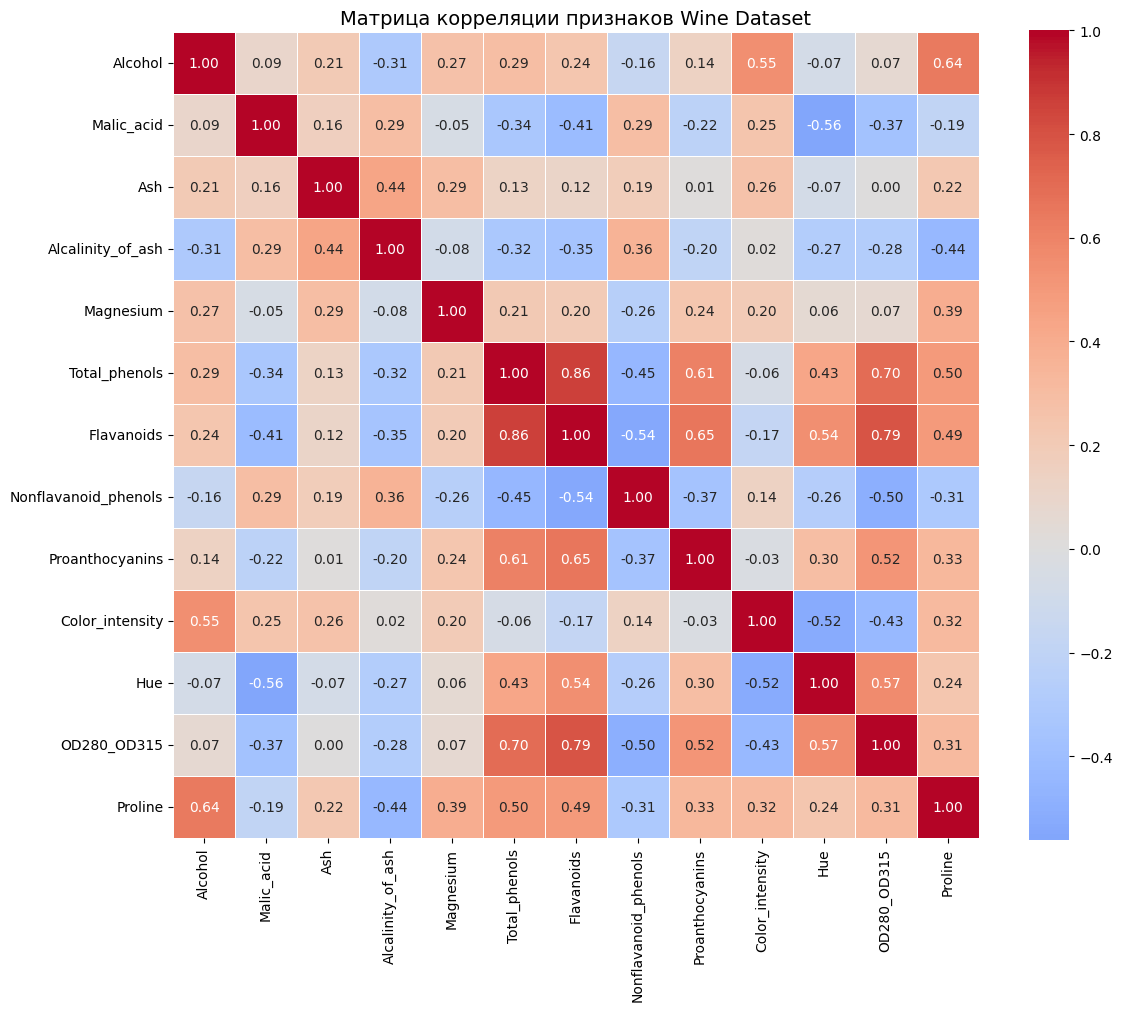

In [22]:

corr_matrix = X.corr(method='pearson')
plt.figure(figsize=(12, 10))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5
)

plt.title('Матрица корреляции признаков Wine Dataset', fontsize=14)
plt.tight_layout()
plt.show()

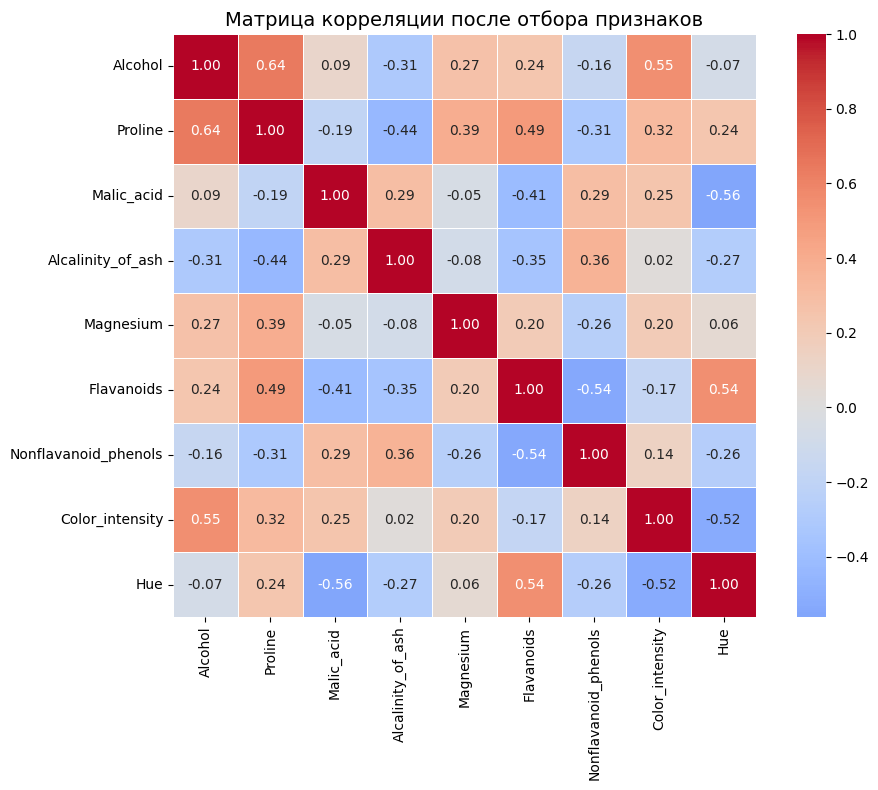

In [38]:
threshold = 0.75

high_corr_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i):
        corr_val = corr_matrix.iloc[i, j]
        if abs(corr_val) >= threshold:
            high_corr_pairs.append((
                corr_matrix.columns[i],
                corr_matrix.columns[j],
                corr_val
            ))

high_corr_pairs

selected_features = [
    'Alcohol',
    'Proline',
    'Malic_acid',
    'Alcalinity_of_ash',
    'Magnesium',
    'Flavanoids',
    'Nonflavanoid_phenols',
    'Color_intensity',
    'Hue'
]

X_selected = X[selected_features]
plt.figure(figsize=(10, 8))

sns.heatmap(
    X_selected.corr(),
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5
)

plt.title('Матрица корреляции после отбора признаков', fontsize=14)
plt.tight_layout()
plt.show()


## Стандартизация и ящик с усами

/tmp/ipykernel_4664/201153936.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


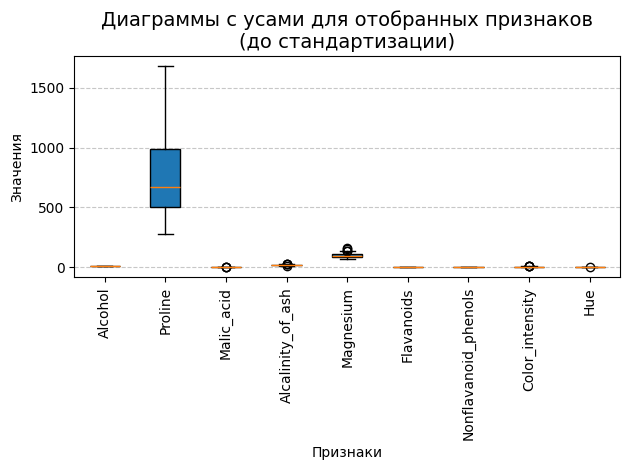

/tmp/ipykernel_4664/201153936.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


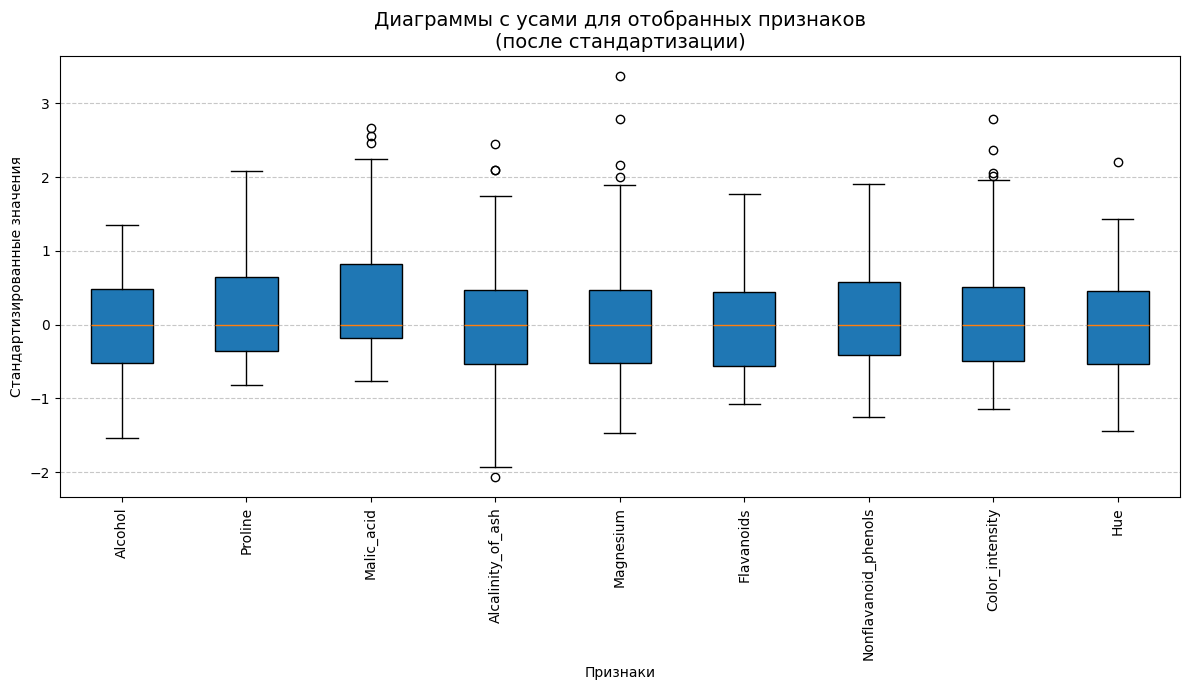

In [39]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler
import pandas as pd

X_selected = X_selected.copy()

plt.boxplot(
    X_selected.values,
    vert=True,
    labels=X_selected.columns,
    patch_artist=True
)

plt.xticks(rotation=90)
plt.title('Диаграммы с усами для отобранных признаков\n(до стандартизации)', fontsize=14)
plt.xlabel('Признаки')
plt.ylabel('Значения')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

scaler = RobustScaler()
X_std = scaler.fit_transform(X_selected)

X_std = pd.DataFrame(X_std, columns=X_selected.columns)

plt.figure(figsize=(12, 7))

plt.boxplot(
    X_std.values,
    vert=True,
    labels=X_std.columns,
    patch_artist=True
)

plt.xticks(rotation=90)
plt.title('Диаграммы с усами для отобранных признаков\n(после стандартизации)', fontsize=14)
plt.xlabel('Признаки')
plt.ylabel('Стандартизированные значения')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### Диаграммы рассеяния

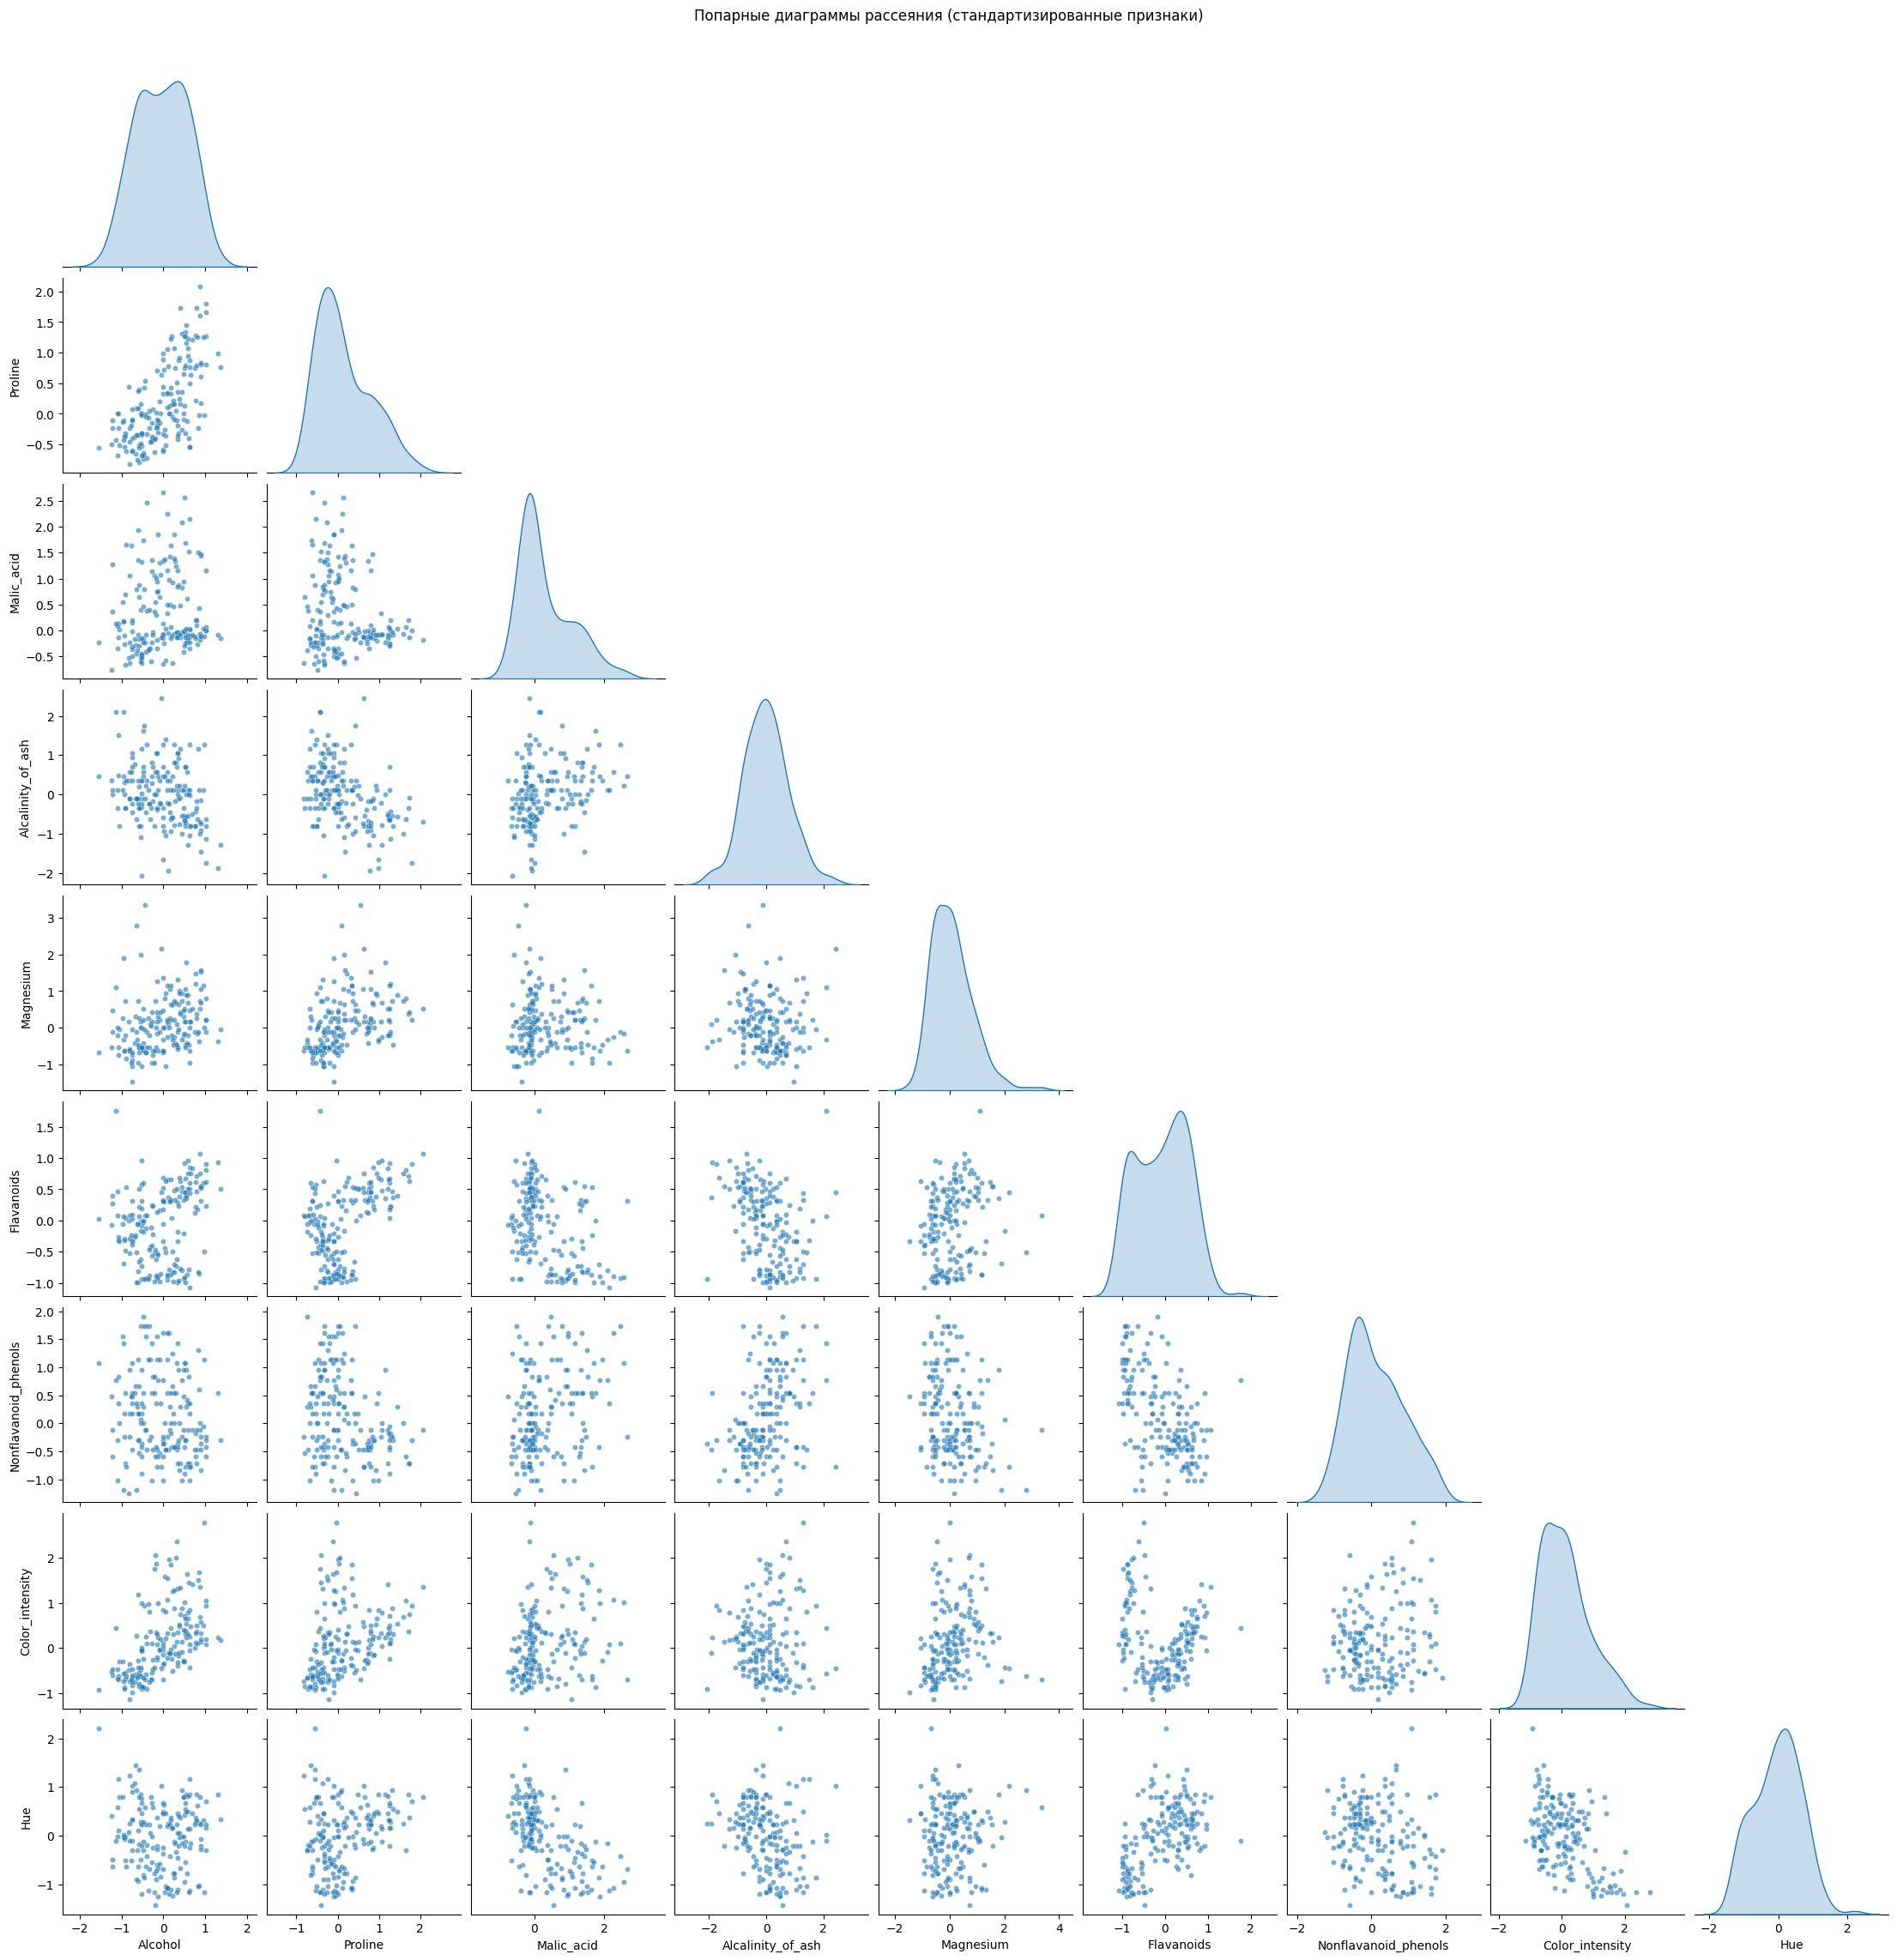

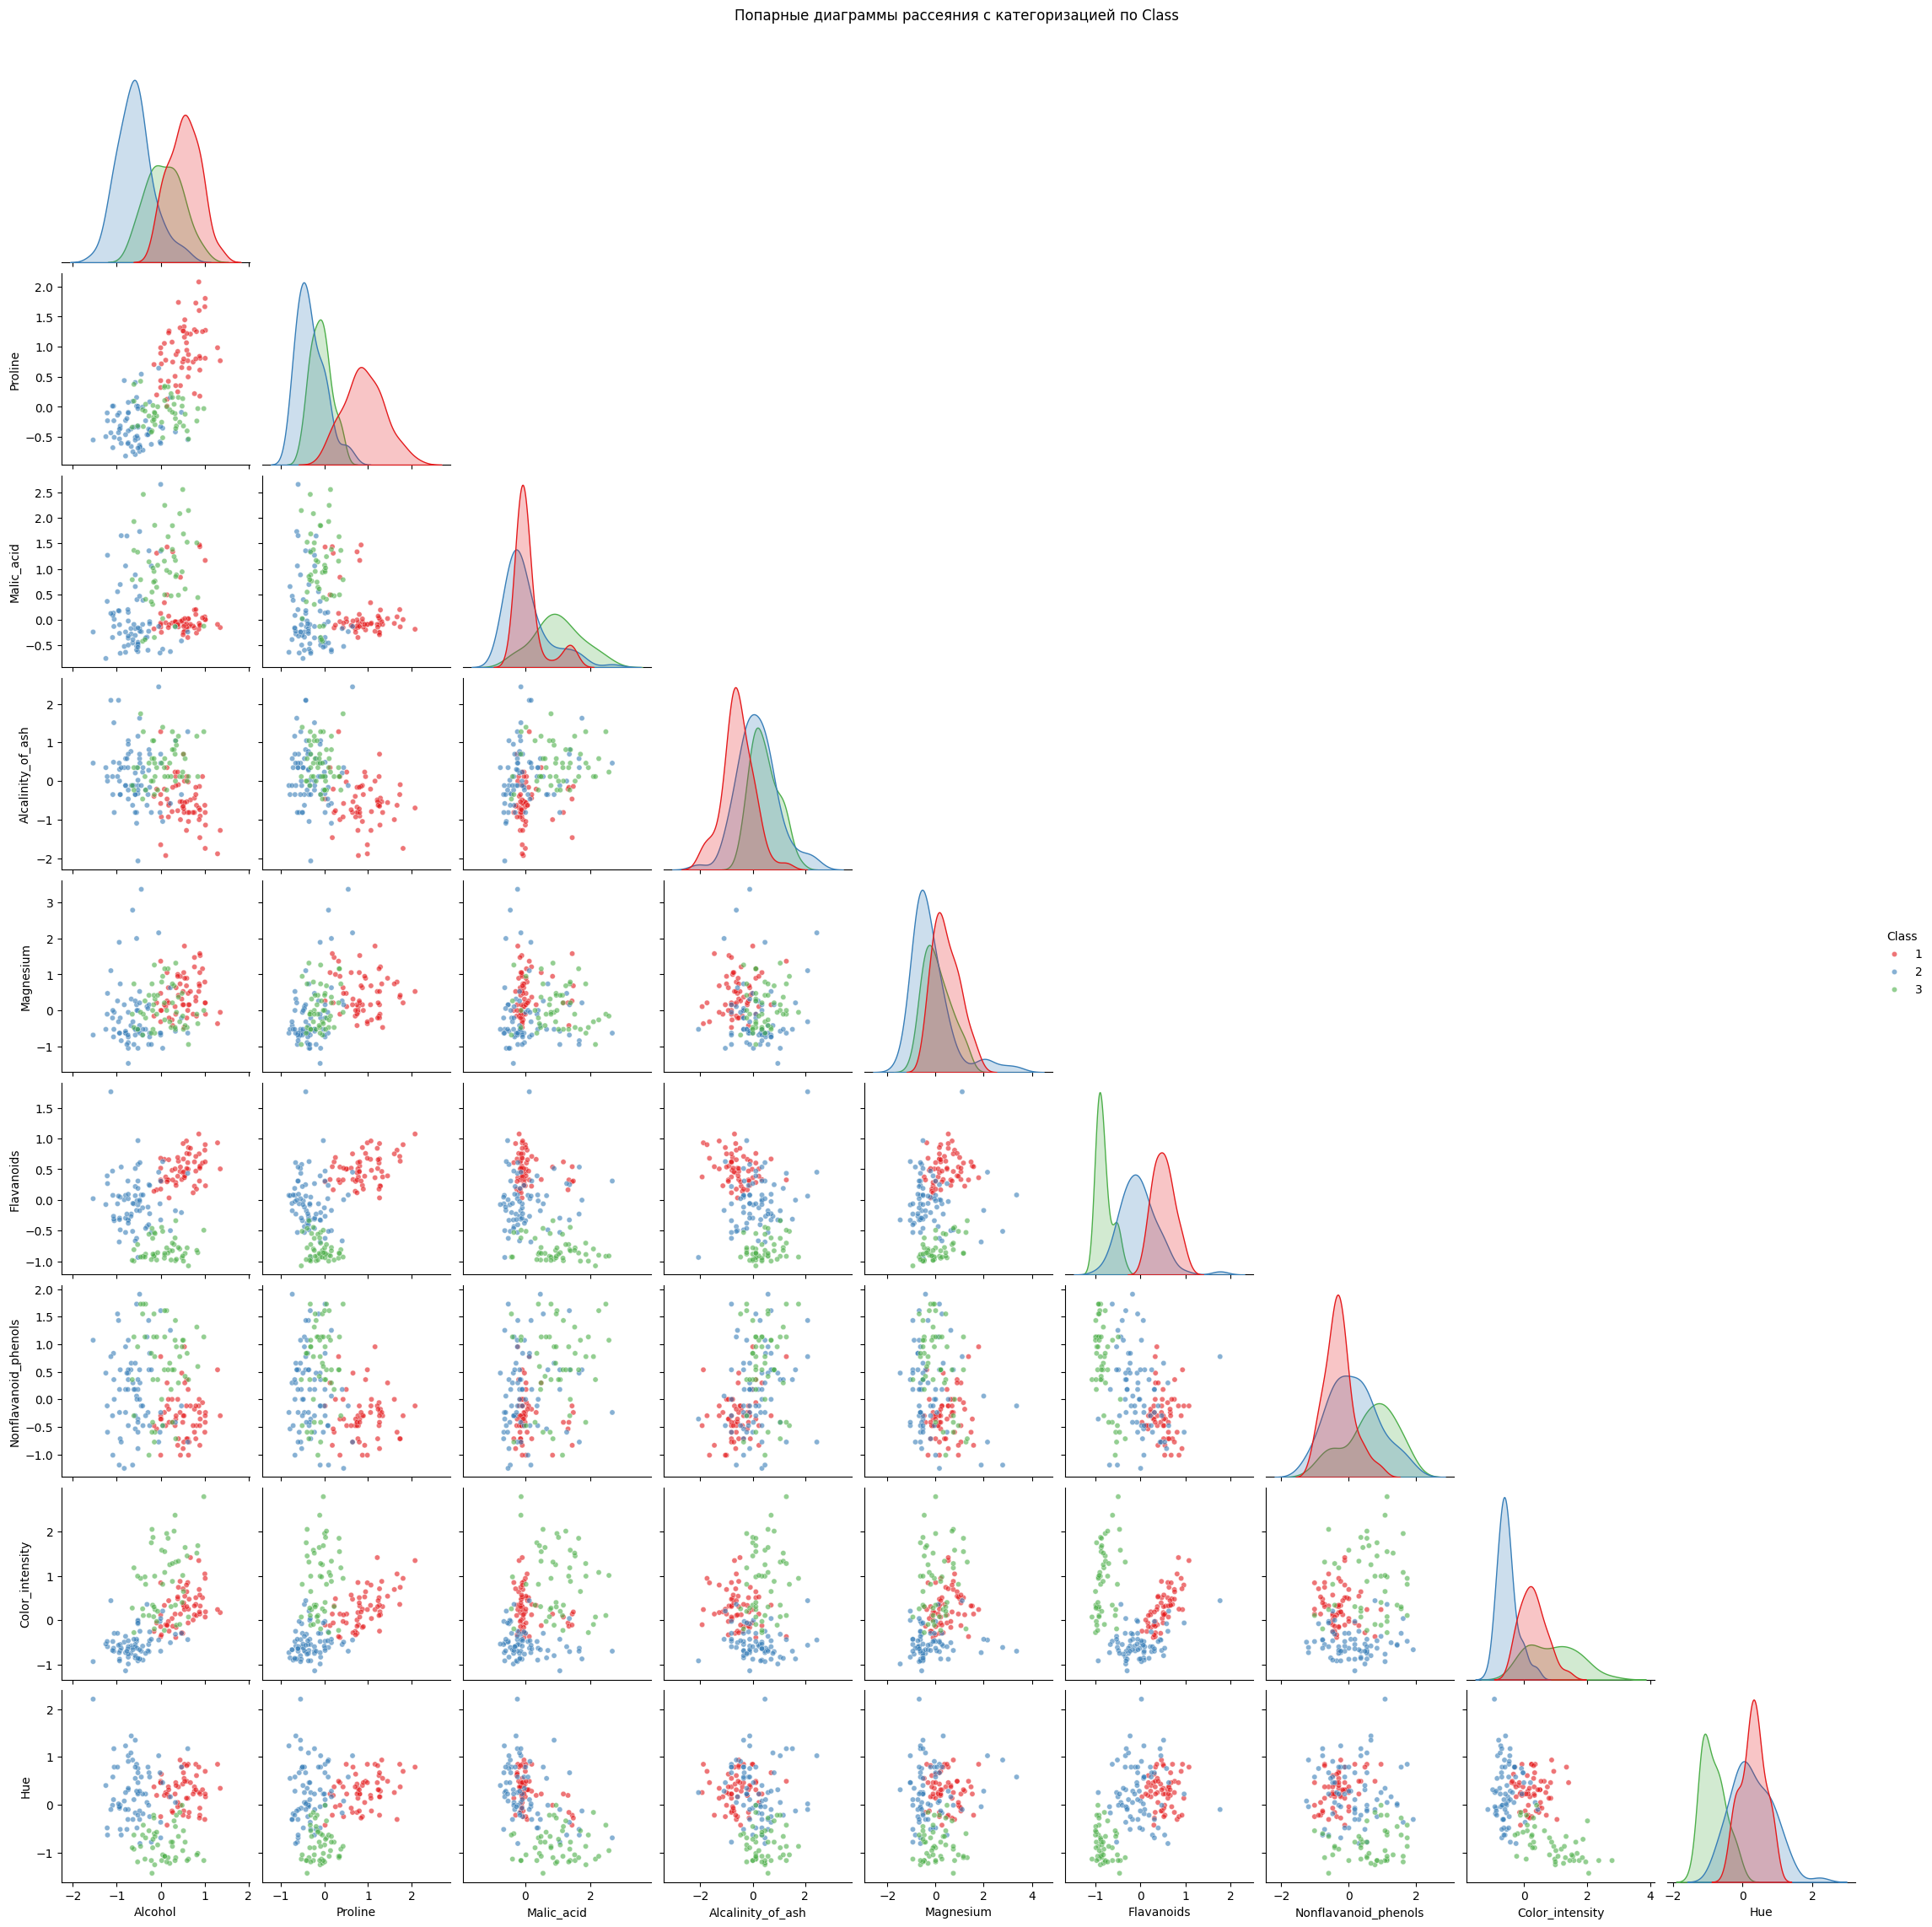

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Убедимся, что отобранные признаки есть
X_selected_std = X_std.copy()  # стандартизированные признаки
X_selected_std['Class'] = data['Class']  # добавляем метку класса для цветовой категории
sns.pairplot(
    X_selected_std,
    vars=X_selected_std.columns[:-1],  # исключаем Class
    diag_kind="kde",
    corner=True,
    plot_kws={"alpha": 0.6, "s": 20}
)
plt.suptitle("Попарные диаграммы рассеяния (стандартизированные признаки)", y=1.02)
plt.show()
sns.pairplot(
    X_selected_std,
    vars=X_selected_std.columns[:-1],  # признаки
    hue="Class",                        # цвет по классу винограда
    diag_kind="kde",
    corner=True,
    plot_kws={"alpha": 0.6, "s": 20},
    palette="Set1"
)
plt.suptitle("Попарные диаграммы рассеяния с категоризацией по Class", y=1.02)
plt.show()


### Подбор числа кластеров

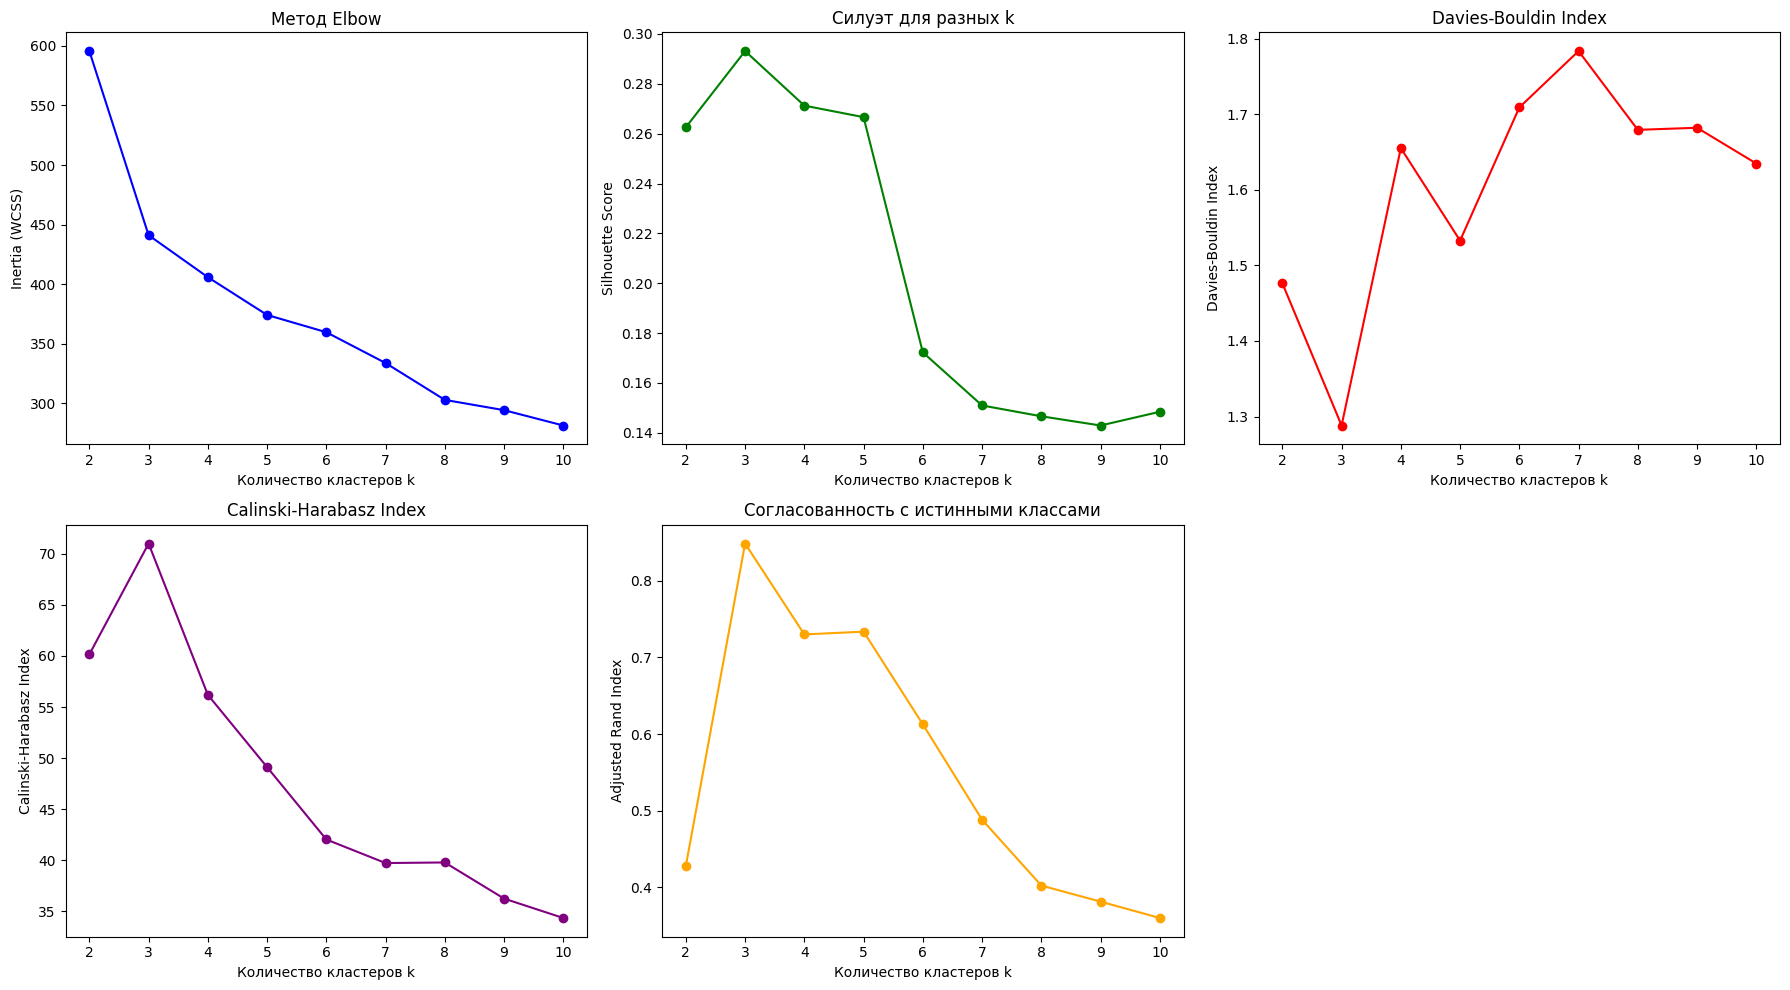

In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.metrics import davies_bouldin_score, calinski_harabasz_score, adjusted_rand_score

# Предполагаем, что X_cluster = X_std без колонки 'Class'
y_true = X_selected_std['Class']  # истинные классы
X_cluster = X_selected_std.drop(columns=['Class'])
K_range = range(2, 11)
# Списки для метрик
dbi_scores = []
chi_scores = []
ari_scores = []
inertia = []
silhouette = []



for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_cluster)
    labels = kmeans.labels_
    inertia.append(kmeans.inertia_)
    silhouette.append(silhouette_score(X_cluster, labels))
    
    # Метрики
    dbi_scores.append(davies_bouldin_score(X_cluster, labels))
    chi_scores.append(calinski_harabasz_score(X_cluster, labels))
    ari_scores.append(adjusted_rand_score(y_true, labels))

# Строим графики
plt.figure(figsize=(18,10))

# Elbow
plt.subplot(2,3,1)
plt.plot(K_range, inertia, 'o-', color='blue')
plt.xlabel('Количество кластеров k')
plt.ylabel('Inertia (WCSS)')
plt.title('Метод Elbow')

# Silhouette
plt.subplot(2,3,2)
plt.plot(K_range, silhouette, 'o-', color='green')
plt.xlabel('Количество кластеров k')
plt.ylabel('Silhouette Score')
plt.title('Силуэт для разных k')

# Davies-Bouldin Index
plt.subplot(2,3,3)
plt.plot(K_range, dbi_scores, 'o-', color='red')
plt.xlabel('Количество кластеров k')
plt.ylabel('Davies-Bouldin Index')
plt.title('Davies-Bouldin Index')

# Calinski-Harabasz Index
plt.subplot(2,3,4)
plt.plot(K_range, chi_scores, 'o-', color='purple')
plt.xlabel('Количество кластеров k')
plt.ylabel('Calinski-Harabasz Index')
plt.title('Calinski-Harabasz Index')

# Adjusted Rand Index
plt.subplot(2,3,5)
plt.plot(K_range, ari_scores, 'o-', color='orange')
plt.xlabel('Количество кластеров k')
plt.ylabel('Adjusted Rand Index')
plt.title('Согласованность с истинными классами')

plt.tight_layout()
plt.show()




### Задача классификации k-means

Метрики KMeans (k = 3):
Средний силуэт           : 0.2931
Индекс Калински–Харабаса : 71.0148
Индекс Дэвиса–Болдина    : 1.2881
ARI                      : 0.8486


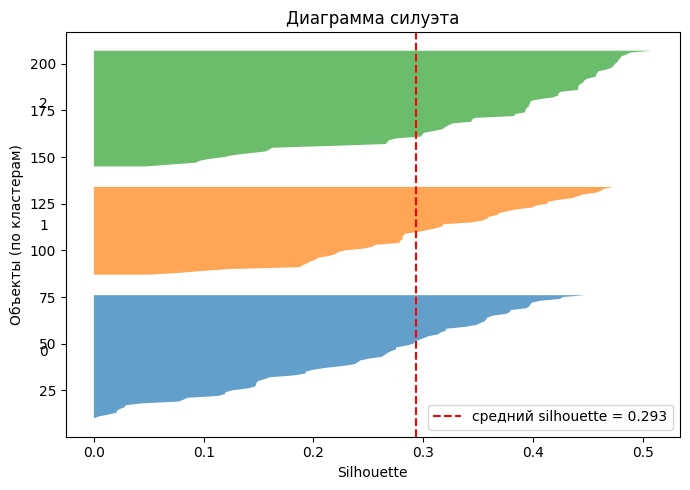


Центры кластеров (в пространстве стандартизованных признаков):


,Alcohol,Proline,Malic_acid,Alcalinity_of_ash,Magnesium,Flavanoids,Nonflavanoid_phenols,Color_intensity,Hue
cluster_0,-0.602690,-0.340234,0.005294,0.167650,-0.316575,-0.040888,0.194253,-0.529150,0.258308
cluster_1,0.090463,-0.106553,1.091920,0.486919,0.029605,-0.780439,0.654229,0.893107,-0.832716
cluster_2,0.465930,0.871017,0.062259,-0.552602,0.573099,0.459224,-0.336413,0.231277,0.296531


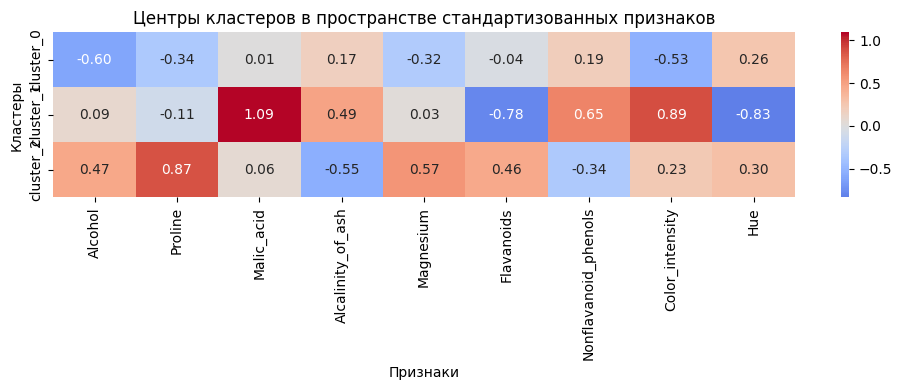


Характеристики кластеров (внутрикластерные расстояния / компактность):


,cluster,size,mean_dist_to_center,std_dist_to_center,within_cluster_SSE
0,0,67,1.546587,0.536255,179.526616
1,1,48,1.545730,0.422329,123.246851
2,2,63,1.361495,0.585595,138.385185



Расстояния между центрами кластеров (евклидовы):


,cluster_0,cluster_1,cluster_2
cluster_0,0.000000,2.430896,2.243666
cluster_1,2.430896,0.000000,2.786426
cluster_2,2.243666,2.786426,0.000000


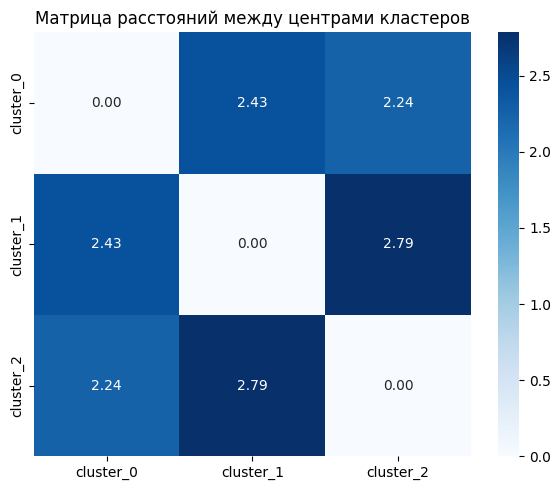


Значимость признаков по кластерам (односторонний ANOVA, KMeans):


,feature,F_stat,p_value
0,Alcohol,113.925482,2.068682e-32
1,Proline,199.946291,6.338588e-46
2,Malic_acid,56.154486,1.446356e-19
3,Alcalinity_of_ash,38.296084,1.602623e-14
4,Magnesium,30.661443,3.837722e-12
5,Flavanoids,171.399169,5.980978e-42
6,Nonflavanoid_phenols,33.705455,4.144910e-13
7,Color_intensity,102.160605,4.005952e-30
8,Hue,99.540286,1.353251e-29


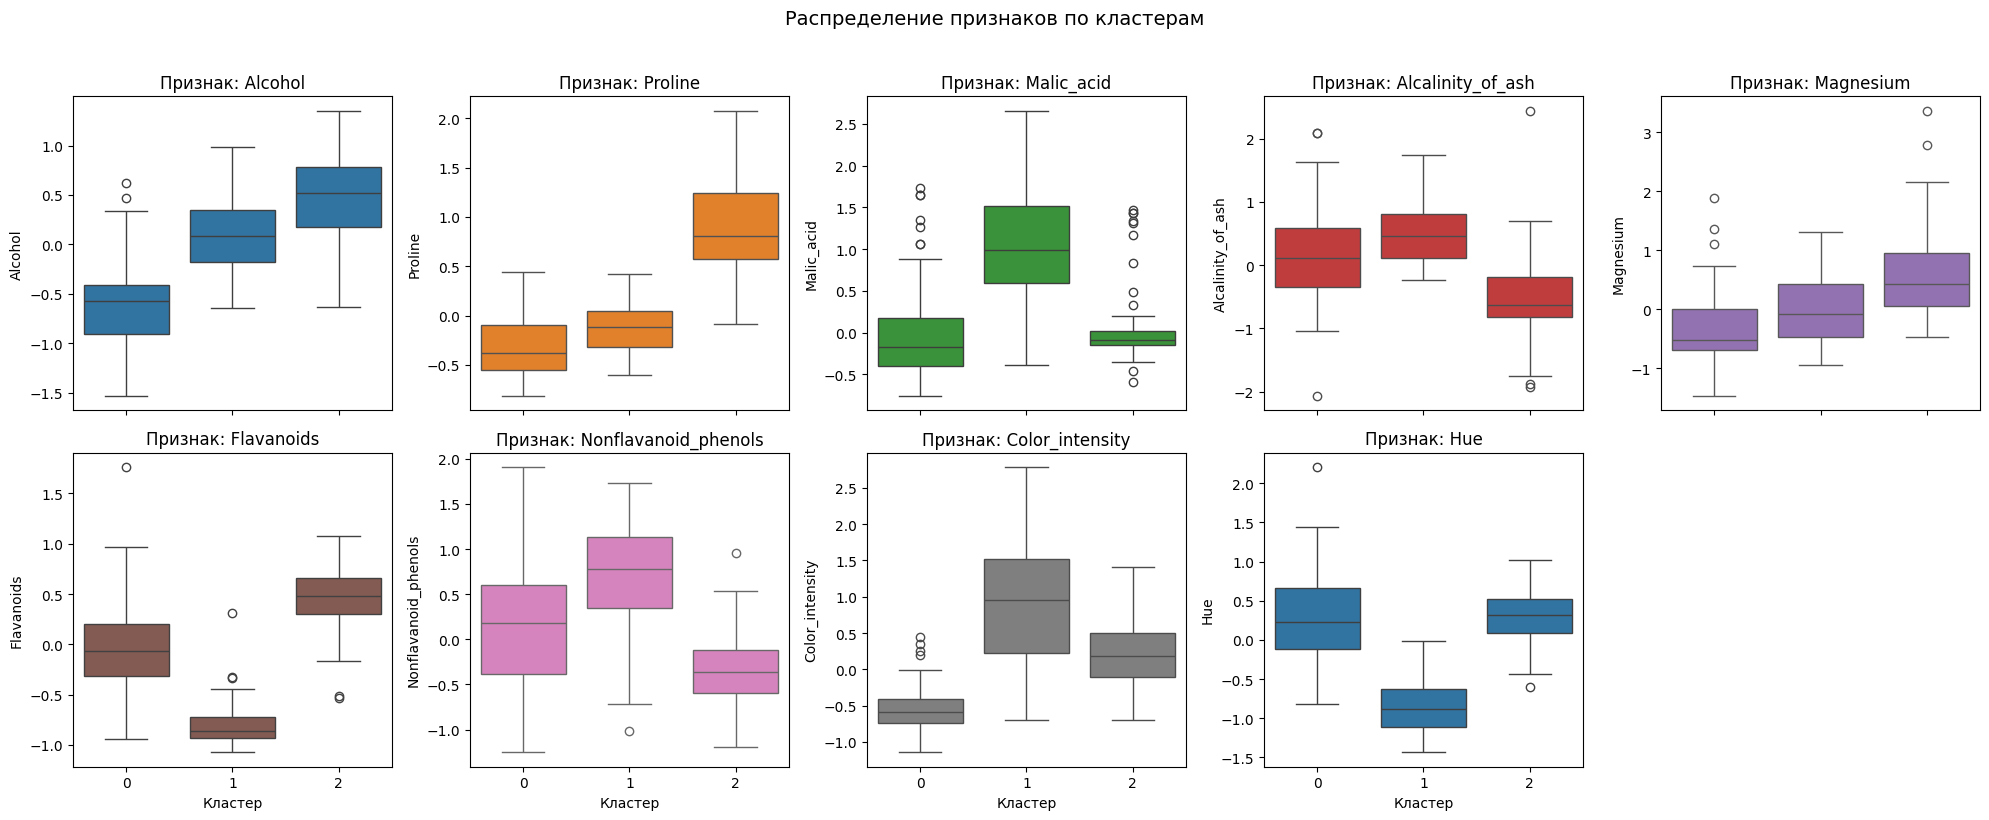

In [49]:
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_samples,
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    adjusted_rand_score,
    pairwise_distances,
)
from scipy.stats import f_oneway
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# используем стандартизированные признаки
X_scaled = X_std.copy()
y_true = X_selected_std['Class'] = data['Class']

# количество кластеров
k = 3  # для Wine dataset логично k=3

# K-means
kmeans = KMeans(
    n_clusters=k,
    init="k-means++",
    n_init=10,
    random_state=42,
)
kmeans.fit(X_scaled)
labels = kmeans.labels_

# метрики качества
sil_samples = silhouette_samples(X_scaled, labels)
sil = silhouette_score(X_scaled, labels)
ch = calinski_harabasz_score(X_scaled, labels)
db = davies_bouldin_score(X_scaled, labels)
ari = adjusted_rand_score(y_true, labels)

print(f"Метрики KMeans (k = {k}):")
print(f"Средний силуэт           : {sil:.4f}")
print(f"Индекс Калински–Харабаса : {ch:.4f}")
print(f"Индекс Дэвиса–Болдина    : {db:.4f}")
print(f"ARI                      : {ari:.4f}")

# Диаграмма силуэта
fig, ax = plt.subplots(figsize=(7, 5))

y_lower = 10
for c in range(k):
    sil_c = sil_samples[labels == c]
    sil_c.sort()
    size_c = sil_c.shape[0]
    y_upper = y_lower + size_c

    ax.fill_betweenx(
        np.arange(y_lower, y_upper),
        0, sil_c,
        alpha=0.7,
    )
    ax.text(-0.05, y_lower + 0.5 * size_c, str(c))
    y_lower = y_upper + 10

ax.axvline(x=sil, color="red", linestyle="--",
           label=f"средний silhouette = {sil:.3f}")
ax.set_title(f"Диаграмма силуэта")
ax.set_xlabel("Silhouette")
ax.set_ylabel("Объекты (по кластерам)")
ax.legend(loc="best")

plt.tight_layout()
plt.show()

# Центры кластеров и внутрикластерные расстояния
centers = kmeans.cluster_centers_ 

print("\nЦентры кластеров (в пространстве стандартизованных признаков):")
centers_df = pd.DataFrame(centers, columns=X_scaled.columns)
centers_df.index = [f"cluster_{c}" for c in range(k)]
display(centers_df)

plt.figure(figsize=(10, 4))
sns.heatmap(
    centers_df,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Центры кластеров в пространстве стандартизованных признаков")
plt.xlabel("Признаки")
plt.ylabel("Кластеры")
plt.tight_layout()
plt.show()

# расстояния от объектов до центров
dist_to_centers = pairwise_distances(X_scaled, centers)

cluster_stats = []
for c in range(k):
    mask = (labels == c)
    n_c = mask.sum()
    if n_c == 0:
        mean_dist = np.nan
        std_dist = np.nan
        sse_c = np.nan
    else:
        dists_c = dist_to_centers[mask, c]
        mean_dist = dists_c.mean()
        std_dist = dists_c.std()
        sse_c = (dists_c ** 2).sum()

    cluster_stats.append({
        "cluster": c,
        "size": n_c,
        "mean_dist_to_center": mean_dist,
        "std_dist_to_center": std_dist,
        "within_cluster_SSE": sse_c,
    })

print("\nХарактеристики кластеров (внутрикластерные расстояния / компактность):")
cluster_stats_df = pd.DataFrame(cluster_stats)
display(cluster_stats_df)

# расстояния между центрами кластеров
center_dists = pairwise_distances(centers, centers)
center_dists_df = pd.DataFrame(
    center_dists,
    index=[f"cluster_{c}" for c in range(k)],
    columns=[f"cluster_{c}" for c in range(k)]
)

print("\nРасстояния между центрами кластеров (евклидовы):")
display(center_dists_df)

plt.figure(figsize=(6, 5))
sns.heatmap(center_dists_df, annot=True, fmt=".2f", cmap="Blues")
plt.title("Матрица расстояний между центрами кластеров")
plt.tight_layout()
plt.show()

# ANOVA для признаков по кластерам
X_df = X_scaled.copy()
X_df["cluster"] = labels
X_df["class"] = y_true

feature_cols = [c for c in X_df.columns if c not in ["cluster", "class"]]

anova_rows = []
for feat in feature_cols:
    groups = [X_df.loc[labels == c, feat] for c in range(k) if (labels == c).sum() > 1]
    if len(groups) > 1:
        F, p = f_oneway(*groups)
    else:
        F, p = np.nan, np.nan
    anova_rows.append({
        "feature": feat,
        "F_stat": F,
        "p_value": p,
    })

anova_df = pd.DataFrame(anova_rows)
print("\nЗначимость признаков по кластерам (односторонний ANOVA, KMeans):")
display(anova_df)

# Boxplot'ы признаков по кластерам
colors = ["tab:blue", "tab:orange", "tab:green", "tab:red",
          "tab:purple", "tab:brown", "tab:pink", "tab:gray"]

n_feats = len(feature_cols)
n_rows = 2
n_cols = int(np.ceil(n_feats / n_rows))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows), sharex=True)
axes = np.array(axes).ravel()

for i, feat in enumerate(feature_cols):
    ax = axes[i]
    sns.boxplot(
        data=X_df,
        x="cluster",
        y=feat,
        ax=ax,
        color=colors[i % len(colors)],
    )
    ax.set_title(f"Признак: {feat}")
    ax.set_xlabel("Кластер")
    ax.set_ylabel(feat)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Распределение признаков по кластерам", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()


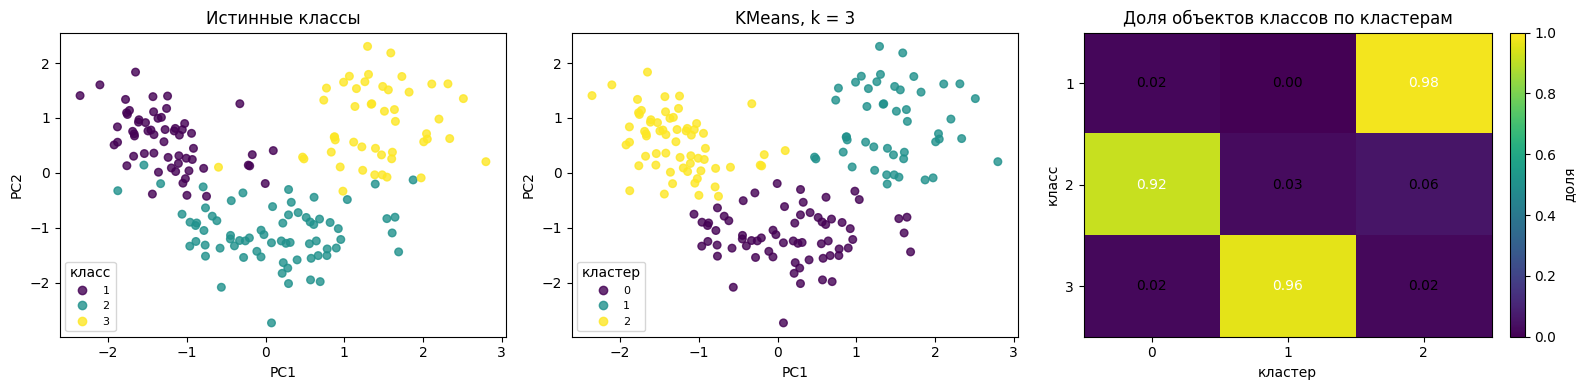

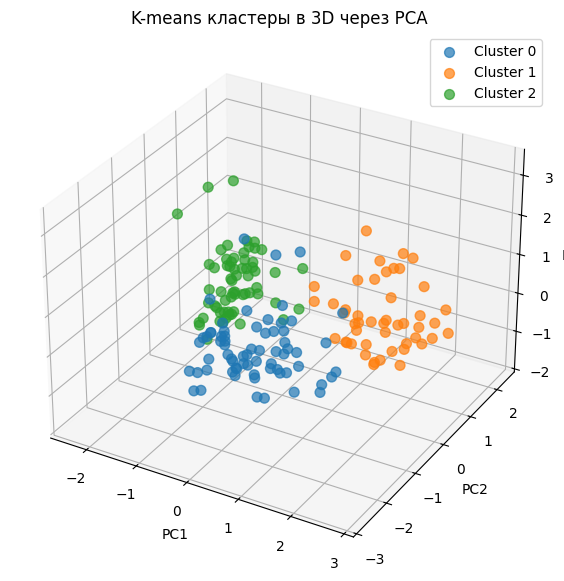

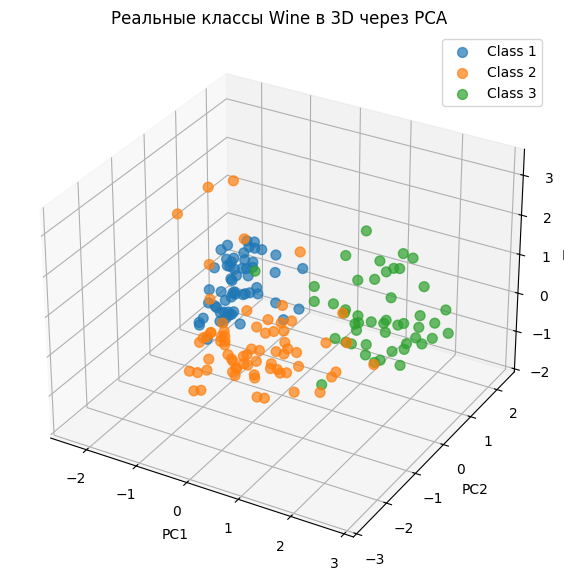

In [50]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# количество кластеров
k = 3  # Wine dataset имеет 3 сорта

# K-means
kmeans = KMeans(
    n_clusters=k,
    init="k-means++",
    n_init=10,
    random_state=42,
)
kmeans.fit(X_std)
km_labels = kmeans.labels_

# PCA 2D
X_pca = PCA(n_components=2, random_state=42).fit_transform(X_std)

y = X_selected_std['Class'] = data['Class']
# кодирование классов
y_codes, y_classes = pd.factorize(y)

# матрица распределения классов по кластерам
cm_counts = pd.crosstab(pd.Series(y, name="class"), pd.Series(km_labels, name="cluster"))
cm = cm_counts.div(cm_counts.sum(axis=1), axis=0)

# графики
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 4))

# Истинные классы
sc1 = ax1.scatter(X_pca[:, 0], X_pca[:, 1], c=y_codes, s=30, alpha=0.8)
ax1.set_title("Истинные классы")
ax1.set_xlabel("PC1")
ax1.set_ylabel("PC2")
handles1, _ = sc1.legend_elements()
ax1.legend(handles1, y_classes.astype(str), title="класс", loc="best", fontsize=8)

# K-means кластеры
sc2 = ax2.scatter(X_pca[:, 0], X_pca[:, 1], c=km_labels, s=30, alpha=0.8)
ax2.set_title(f"KMeans, k = {k}")
ax2.set_xlabel("PC1")
ax2.set_ylabel("PC2")
handles2, _ = sc2.legend_elements()
ax2.legend(handles2, sorted(np.unique(km_labels)), title="кластер", loc="best", fontsize=8)

# Тепловая карта распределения классов по кластерам
im = ax3.imshow(cm.values, vmin=0, vmax=1, aspect="auto", cmap="viridis")
ax3.set_title("Доля объектов классов по кластерам")
ax3.set_xlabel("кластер")
ax3.set_ylabel("класс")
ax3.set_xticks(np.arange(cm.shape[1]))
ax3.set_yticks(np.arange(cm.shape[0]))
ax3.set_xticklabels(cm.columns)
ax3.set_yticklabels(cm.index)

# подписи внутри клеток
for (i, j), v in np.ndenumerate(cm.values):
    ax3.text(j, i, f"{v:.2f}", ha="center", va="center", color="white" if v > 0.5 else "black")

cbar = fig.colorbar(im, ax=ax3, fraction=0.046, pad=0.04)
cbar.set_label("доля", rotation=90)

plt.tight_layout()
plt.show()


X_pca3 = PCA(n_components=3, random_state=42).fit_transform(X_std)
pca3_df = pd.DataFrame(X_pca3, columns=["PC1", "PC2", "PC3"])
pca3_df["cluster"] = labels  # K-means метки
pca3_df["class"] = y_true    # реальные классы
fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

for c in sorted(pca3_df["cluster"].unique()):
    mask = pca3_df["cluster"] == c
    ax.scatter(
        pca3_df.loc[mask, "PC1"],
        pca3_df.loc[mask, "PC2"],
        pca3_df.loc[mask, "PC3"],
        s=50,
        alpha=0.7,
        label=f"Cluster {c}"
    )

ax.set_title("K-means кластеры в 3D через PCA")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.legend()
plt.show()

# 3D график реальных классов
fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

for cls in sorted(pca3_df["class"].unique()):
    mask = pca3_df["class"] == cls
    ax.scatter(
        pca3_df.loc[mask, "PC1"],
        pca3_df.loc[mask, "PC2"],
        pca3_df.loc[mask, "PC3"],
        s=50,
        alpha=0.7,
        label=f"Class {cls}"
    )

ax.set_title("Реальные классы Wine в 3D через PCA")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.legend()
plt.show()

## GMM

### Подбор параметров

<Figure size 2000x1200 with 0 Axes>

<Figure size 2000x1200 with 0 Axes>

<Figure size 2000x1200 with 0 Axes>

<Figure size 2000x1200 with 0 Axes>

<Figure size 2000x1200 with 0 Axes>

<Figure size 2000x1200 with 0 Axes>

<Figure size 2000x1200 with 0 Axes>

<Figure size 2000x1200 with 0 Axes>

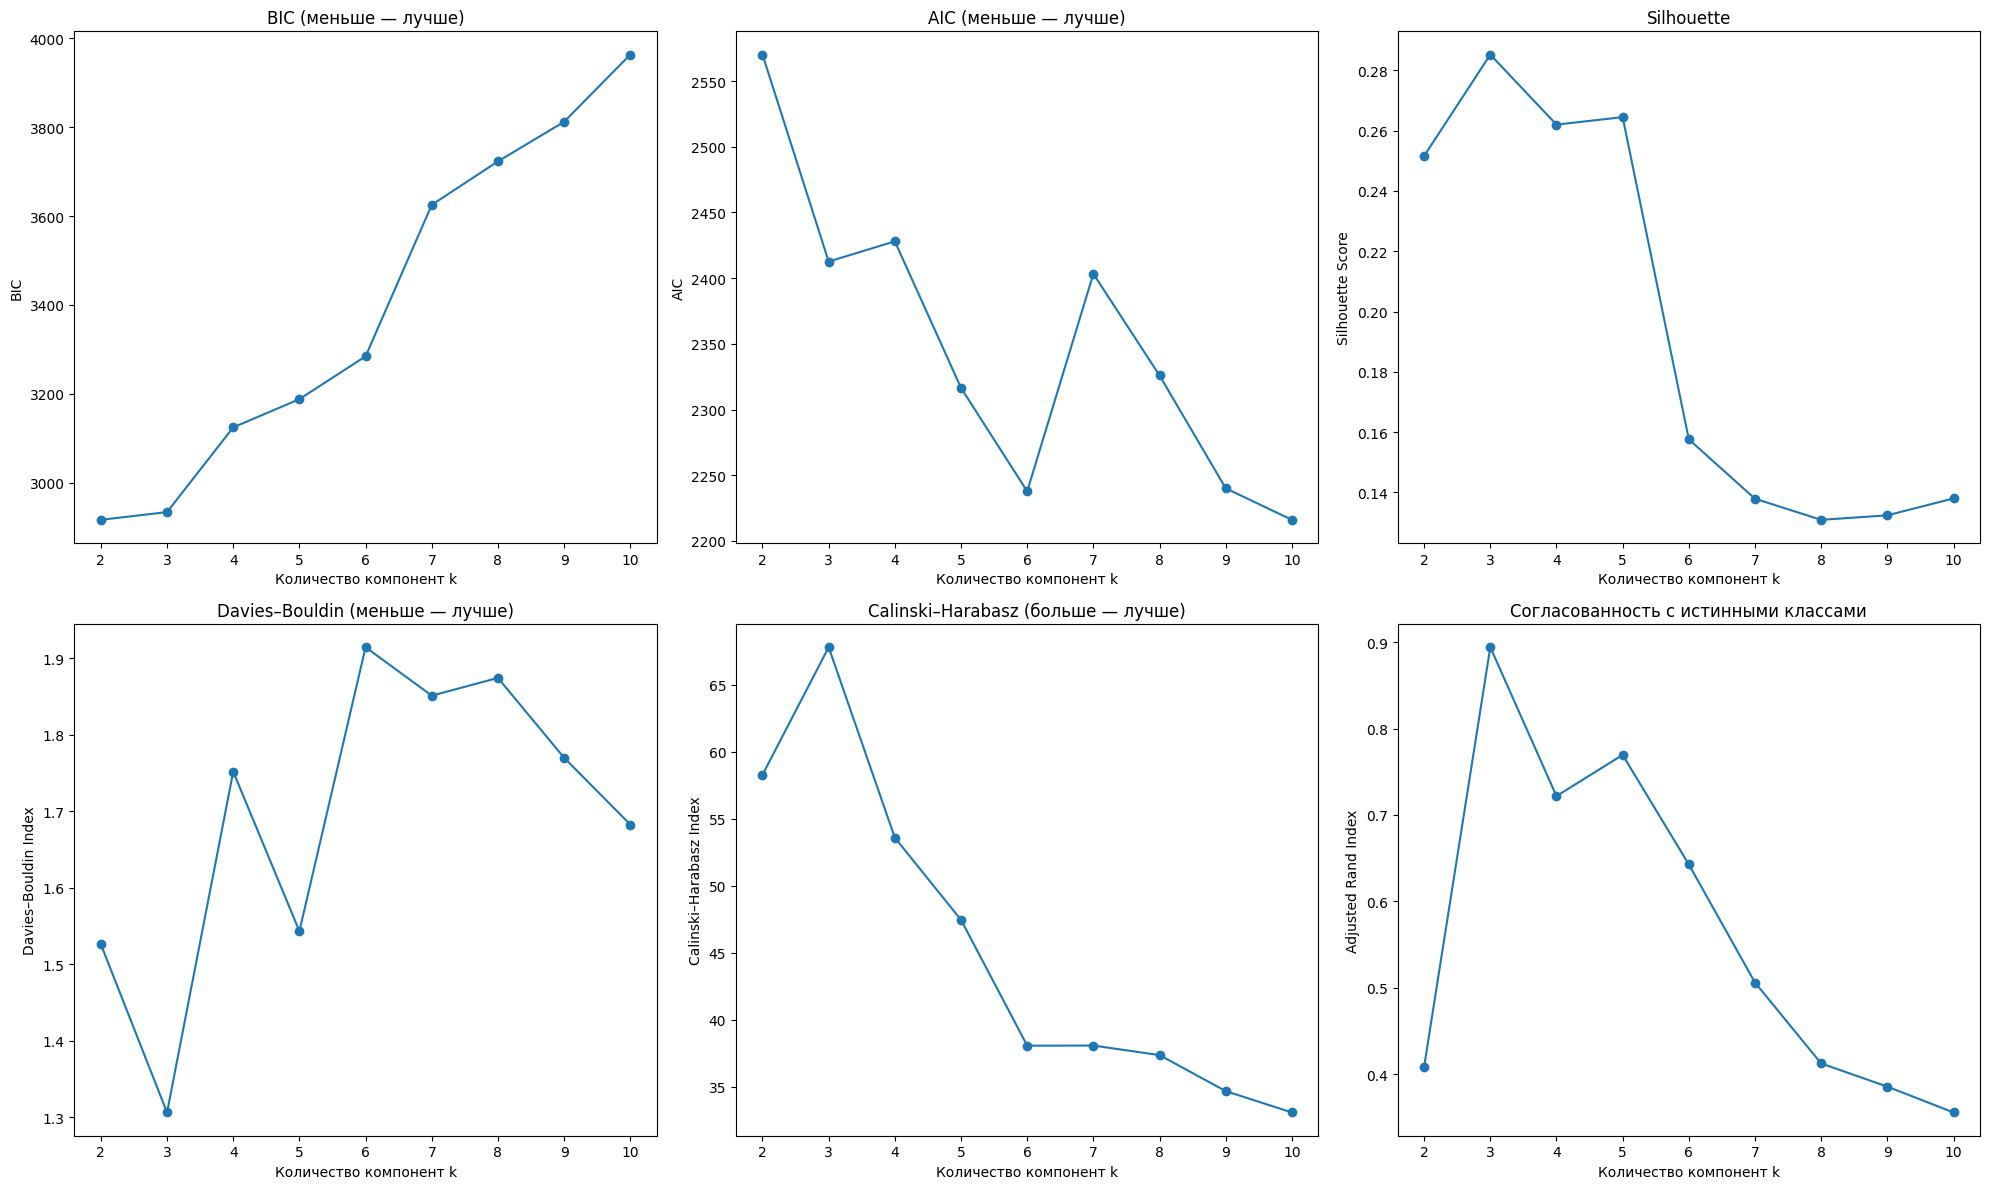

In [51]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.mixture import GaussianMixture
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    adjusted_rand_score
)

# Истинные классы
y_true = X_selected_std['Class']
X_cluster = X_selected_std.drop(columns=['Class'])

# Диапазон k
K_range = range(2, 11)

# Метрики
bic_scores = []
aic_scores = []
silhouette_scores = []
dbi_scores = []
chi_scores = []
ari_scores = []

for k in K_range:
    gmm = GaussianMixture(
        n_components=k,
        covariance_type='full',
        random_state=42
    )
    
    gmm.fit(X_cluster)
    labels = gmm.predict(X_cluster)
    
    # Информационные критерии
    bic_scores.append(gmm.bic(X_cluster))
    aic_scores.append(gmm.aic(X_cluster))
    
    # Кластерные метрики
    silhouette_scores.append(silhouette_score(X_cluster, labels))
    dbi_scores.append(davies_bouldin_score(X_cluster, labels))
    chi_scores.append(calinski_harabasz_score(X_cluster, labels))
    ari_scores.append(adjusted_rand_score(y_true, labels))

    plt.figure(figsize=(20,12))

# BIC
plt.subplot(2,3,1)
plt.plot(K_range, bic_scores, 'o-')
plt.xlabel('Количество компонент k')
plt.ylabel('BIC')
plt.title('BIC (меньше — лучше)')

# AIC
plt.subplot(2,3,2)
plt.plot(K_range, aic_scores, 'o-')
plt.xlabel('Количество компонент k')
plt.ylabel('AIC')
plt.title('AIC (меньше — лучше)')

# Silhouette
plt.subplot(2,3,3)
plt.plot(K_range, silhouette_scores, 'o-')
plt.xlabel('Количество компонент k')
plt.ylabel('Silhouette Score')
plt.title('Silhouette')

# Davies–Bouldin
plt.subplot(2,3,4)
plt.plot(K_range, dbi_scores, 'o-')
plt.xlabel('Количество компонент k')
plt.ylabel('Davies–Bouldin Index')
plt.title('Davies–Bouldin (меньше — лучше)')

# Calinski–Harabasz
plt.subplot(2,3,5)
plt.plot(K_range, chi_scores, 'o-')
plt.xlabel('Количество компонент k')
plt.ylabel('Calinski–Harabasz Index')
plt.title('Calinski–Harabasz (больше — лучше)')

# ARI
plt.subplot(2,3,6)
plt.plot(K_range, ari_scores, 'o-')
plt.xlabel('Количество компонент k')
plt.ylabel('Adjusted Rand Index')
plt.title('Согласованность с истинными классами')

plt.tight_layout()
plt.show()



### Решение задачи кластеризации с помошью GMM

Метрики GMM (k = 3):
Средний силуэт           : 0.2853
Индекс Калински–Харабаса : 67.7853
Индекс Дэвиса–Болдина    : 1.3063
ARI                      : 0.8943
BIC                      : 2934.46
AIC                      : 2412.65


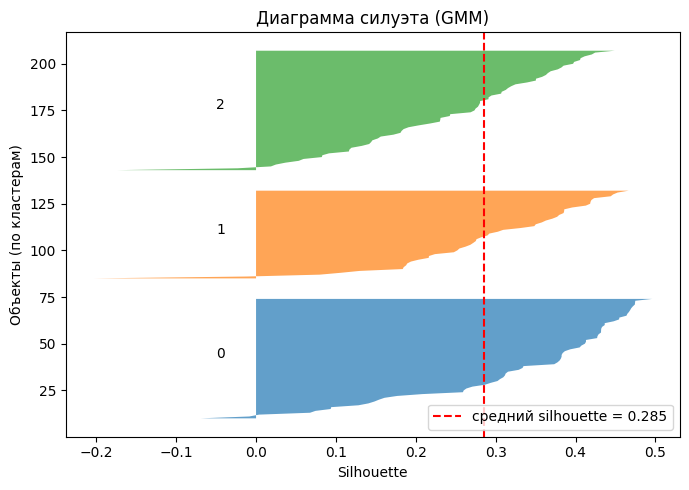

,Alcohol,Proline,Malic_acid,Alcalinity_of_ash,Magnesium,Flavanoids,Nonflavanoid_phenols,Color_intensity,Hue
component_0,0.426532,0.856796,0.054442,-0.497061,0.587064,0.448249,-0.339537,0.202217,0.308546
component_1,0.078012,-0.089823,0.991496,0.445704,0.070327,-0.810367,0.640432,0.906597,-0.835673
component_2,-0.584884,-0.372726,0.084808,0.162840,-0.385846,-0.021461,0.222181,-0.532598,0.248212


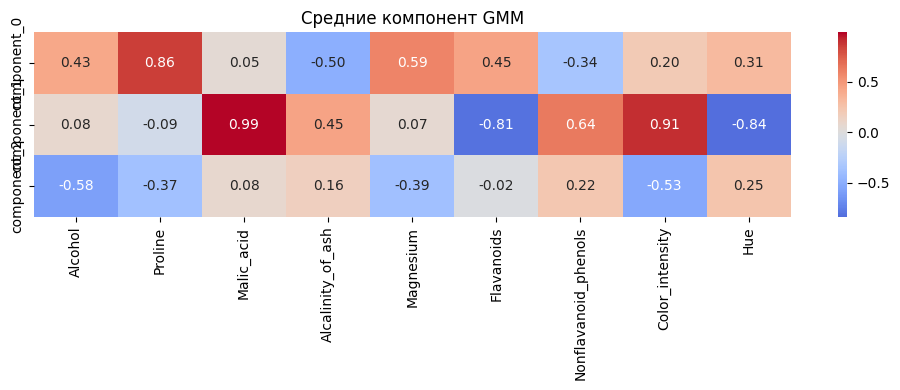

,component,size,mean_dist_to_mean,std_dist_to_mean
0,0,65,1.408602,0.616164
1,1,48,1.556872,0.425363
2,2,65,1.534243,0.535861


,feature,F_stat,p_value
0,Alcohol,90.624266,9.714813e-28
1,Proline,213.294397,1.194269e-47
2,Malic_acid,36.799116,4.568264e-14
3,Alcalinity_of_ash,30.272739,5.120197e-12
4,Magnesium,39.442728,7.244688e-15
5,Flavanoids,197.551167,1.318128e-45
6,Nonflavanoid_phenols,34.245596,2.808952e-13
7,Color_intensity,103.839357,1.852796e-30
8,Hue,101.729937,4.887573e-30


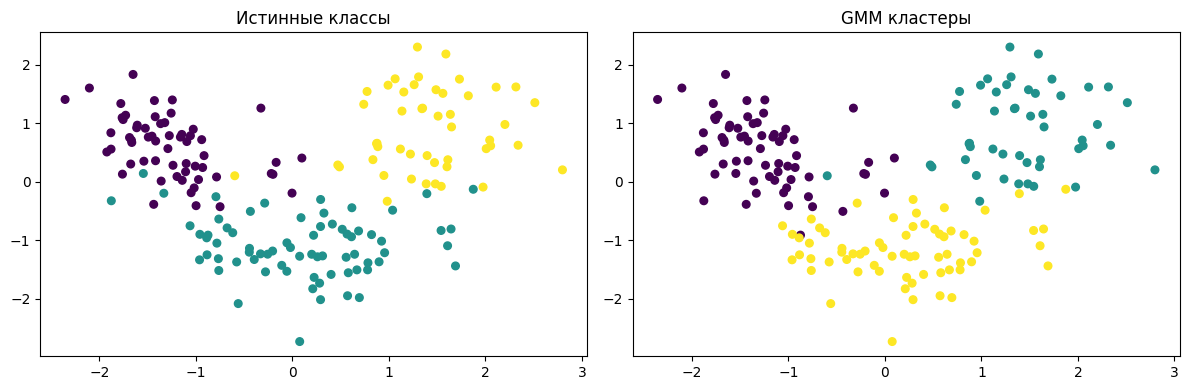

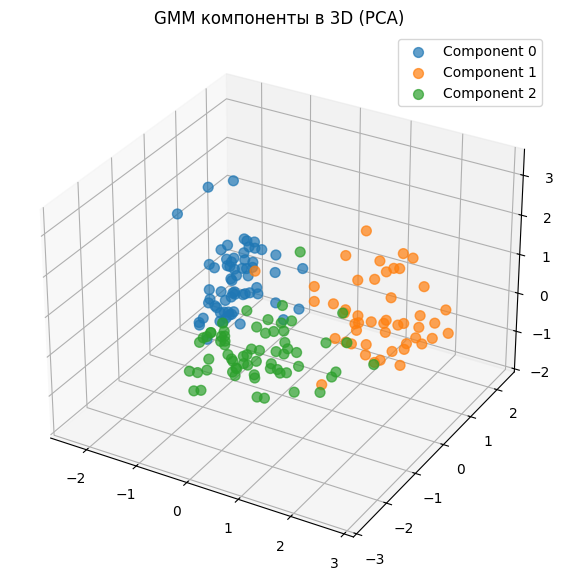

In [52]:
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (
    silhouette_samples,
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    adjusted_rand_score,
)
from sklearn.decomposition import PCA
from scipy.stats import f_oneway
from sklearn.metrics import pairwise_distances
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
X_scaled = X_std.copy()
y_true = X_selected_std['Class'] = data['Class']

k = 3  # Wine dataset
gmm = GaussianMixture(
    n_components=k,
    covariance_type="full",
    n_init=10,
    random_state=42
)

gmm.fit(X_scaled)

labels = gmm.predict(X_scaled)
proba = gmm.predict_proba(X_scaled)  # вероятности принадлежности
sil_samples = silhouette_samples(X_scaled, labels)
sil = silhouette_score(X_scaled, labels)
ch = calinski_harabasz_score(X_scaled, labels)
db = davies_bouldin_score(X_scaled, labels)
ari = adjusted_rand_score(y_true, labels)

bic = gmm.bic(X_scaled)
aic = gmm.aic(X_scaled)

print(f"Метрики GMM (k = {k}):")
print(f"Средний силуэт           : {sil:.4f}")
print(f"Индекс Калински–Харабаса : {ch:.4f}")
print(f"Индекс Дэвиса–Болдина    : {db:.4f}")
print(f"ARI                      : {ari:.4f}")
print(f"BIC                      : {bic:.2f}")
print(f"AIC                      : {aic:.2f}")
fig, ax = plt.subplots(figsize=(7, 5))

y_lower = 10
for c in range(k):
    sil_c = sil_samples[labels == c]
    sil_c.sort()
    size_c = sil_c.shape[0]
    y_upper = y_lower + size_c

    ax.fill_betweenx(
        np.arange(y_lower, y_upper),
        0, sil_c,
        alpha=0.7,
    )
    ax.text(-0.05, y_lower + 0.5 * size_c, str(c))
    y_lower = y_upper + 10

ax.axvline(x=sil, color="red", linestyle="--",
           label=f"средний silhouette = {sil:.3f}")

ax.set_title("Диаграмма силуэта (GMM)")
ax.set_xlabel("Silhouette")
ax.set_ylabel("Объекты (по кластерам)")
ax.legend()
plt.tight_layout()
plt.show()
means = gmm.means_

means_df = pd.DataFrame(means, columns=X_scaled.columns)
means_df.index = [f"component_{c}" for c in range(k)]

display(means_df)

plt.figure(figsize=(10, 4))
sns.heatmap(
    means_df,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Средние компонент GMM")
plt.tight_layout()
plt.show()
dist_to_means = pairwise_distances(X_scaled, means)

cluster_stats = []
for c in range(k):
    mask = labels == c
    n_c = mask.sum()

    if n_c == 0:
        continue

    dists = dist_to_means[mask, c]

    cluster_stats.append({
        "component": c,
        "size": n_c,
        "mean_dist_to_mean": dists.mean(),
        "std_dist_to_mean": dists.std(),
    })

cluster_stats_df = pd.DataFrame(cluster_stats)
display(cluster_stats_df)
X_df = X_scaled.copy()
X_df["cluster"] = labels
X_df["class"] = y_true

feature_cols = [c for c in X_df.columns if c not in ["cluster", "class"]]

anova_rows = []
for feat in feature_cols:
    groups = [X_df.loc[labels == c, feat] for c in range(k) if (labels == c).sum() > 1]
    if len(groups) > 1:
        F, p = f_oneway(*groups)
    else:
        F, p = np.nan, np.nan

    anova_rows.append({
        "feature": feat,
        "F_stat": F,
        "p_value": p,
    })

anova_df = pd.DataFrame(anova_rows)
display(anova_df)
X_pca = PCA(n_components=2, random_state=42).fit_transform(X_scaled)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Реальные классы
y_codes, y_classes = pd.factorize(y_true)
sc1 = ax1.scatter(X_pca[:, 0], X_pca[:, 1], c=y_codes, s=30)
ax1.set_title("Истинные классы")

# GMM
sc2 = ax2.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, s=30)
ax2.set_title("GMM кластеры")

plt.tight_layout()
plt.show()
X_pca3 = PCA(n_components=3, random_state=42).fit_transform(X_scaled)
pca3_df = pd.DataFrame(X_pca3, columns=["PC1", "PC2", "PC3"])
pca3_df["cluster"] = labels
pca3_df["class"] = y_true

fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

for c in sorted(pca3_df["cluster"].unique()):
    mask = pca3_df["cluster"] == c
    ax.scatter(
        pca3_df.loc[mask, "PC1"],
        pca3_df.loc[mask, "PC2"],
        pca3_df.loc[mask, "PC3"],
        s=50,
        alpha=0.7,
        label=f"Component {c}"
    )

ax.set_title("GMM компоненты в 3D (PCA)")
ax.legend()
plt.show()
